<a href="https://colab.research.google.com/github/nurkausarmuner-enka/assignment-03-cnn/blob/main/Assignment_3_CNN_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 2: PyTorch Implementation and Visualization of a CNN**

## 1. Dataset Preparation

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

# 1. Pipeline: transforming images into tensors
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Data Augmentation: reflect the photo to make the model more stable
    transforms.ToTensor(),             # tensor range [0, 1]
    transforms.Normalize((0.5,), (0.5,)) # normalization range [-1, 1]
])

# 2. Loading dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 3. Creating DataLoaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 33.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


## 2. Building the CNN

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Conv Layer 1: 3x3 filter, stride 1, padding 1, 16 output filters
        # Assuming input is 1 channel (Grayscale MNIST)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv Layer 2: 3x3 filter, stride 1, padding 1, 32 output filters
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layer for classification
        # For MNIST (28x28): 32 filters * 7 * 7 = 1568
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        # Layer 1
        x = self.pool1(self.relu1(self.conv1(x)))
        # Layer 2
        x = self.pool2(self.relu2(self.conv2(x)))

        # Flattening the tensor for the FC layer
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Printing summary
from torchsummary import summary
model = SimpleCNN()
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
              ReLU-2           [-1, 16, 28, 28]               0
         MaxPool2d-3           [-1, 16, 14, 14]               0
            Conv2d-4           [-1, 32, 14, 14]           4,640
              ReLU-5           [-1, 32, 14, 14]               0
         MaxPool2d-6             [-1, 32, 7, 7]               0
            Linear-7                   [-1, 10]          15,690
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.32
Params size (MB): 0.08
Estimated Total Size (MB): 0.40
----------------------------------------------------------------


## 3. Training the CNN

In [7]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total

    # Validation phase
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

Epoch [1/5] - Loss: 0.0671, Train Acc: 97.82%, Val Acc: 97.53%
Epoch [2/5] - Loss: 0.0618, Train Acc: 97.97%, Val Acc: 97.18%
Epoch [3/5] - Loss: 0.0583, Train Acc: 98.09%, Val Acc: 97.48%
Epoch [4/5] - Loss: 0.0549, Train Acc: 98.20%, Val Acc: 97.45%
Epoch [5/5] - Loss: 0.0540, Train Acc: 98.17%, Val Acc: 97.41%


## 4. Visualizing Feature Maps

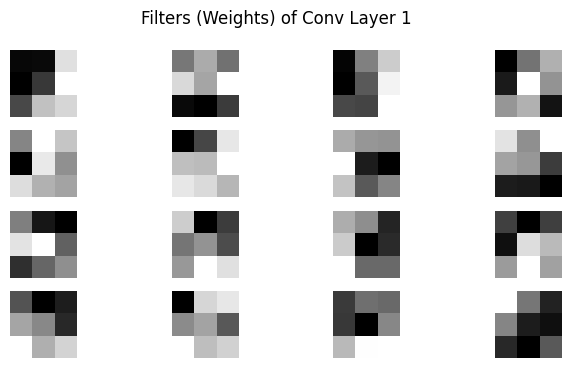

In [8]:
import matplotlib.pyplot as plt

def visualize_feature_maps(model, image):
    # Prepare image (add batch dimension)
    image = image.unsqueeze(0)

    # Extract activations
    conv1 = model.relu1(model.conv1(image))
    pool1 = model.pool1(conv1)
    conv2 = model.relu2(model.conv2(pool1))
    pool2 = model.pool2(conv2)

    # List of activations to plot
    layers = [conv1, pool1, conv2, pool2]
    names = ['Conv1', 'Pool1', 'Conv2', 'Pool2']

    # Plotting
    for name, act in zip(names, layers):
        # We take the first 8 channels to not flood the screen
        plt.figure(figsize=(10, 2))
        for i in range(8):
            plt.subplot(1, 8, i+1)
            plt.imshow(act[0, i].detach().numpy(), cmap='gray')
            plt.axis('off')
        plt.suptitle(f'Output of {name}')
        plt.show()

# Visualize weights of Conv1
weights = model.conv1.weight.data.cpu()
plt.figure(figsize=(8, 4))
for i in range(16): # 16 filters in Conv1
    plt.subplot(4, 4, i+1)
    plt.imshow(weights[i, 0], cmap='gray')
    plt.axis('off')
plt.suptitle('Filters (Weights) of Conv Layer 1')
plt.show()

## 5. Model Evaluation

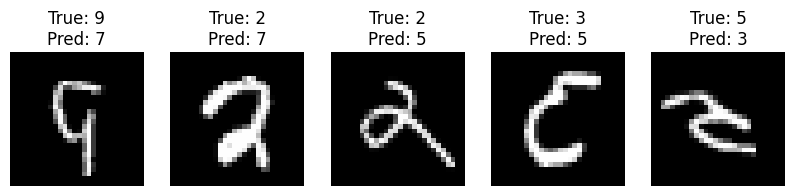

In [9]:
def visualize_errors(model, testloader):
    model.eval()
    errors = []

    with torch.no_grad():
        for inputs, labels in testloader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            # Find indices where model failed
            mask = (predicted != labels)
            for i in range(len(mask)):
                if mask[i]:
                    errors.append((inputs[i], labels[i], predicted[i]))
                    if len(errors) >= 5: break # Collect 5 errors
            if len(errors) >= 5: break

    # Plotting the mistakes
    plt.figure(figsize=(10, 3))
    for i in range(len(errors)):
        img, true_label, pred_label = errors[i]
        plt.subplot(1, 5, i+1)
        plt.imshow(img.squeeze().numpy(), cmap='gray')
        plt.title(f'True: {true_label}\nPred: {pred_label}')
        plt.axis('off')
    plt.show()

visualize_errors(model, testloader)

# **Part 3: Questions for Understanding**

## **Architecture & Design**

We prefer 3x3 kernels because they are computationally cheaper and allow us to use more non-linear activation functions (like ReLU) between layers. A stack of two 3x3 layers covers the same area as one 5x5 layer but uses fewer parameters and creates a more complex, powerful network.


"Valid" padding: No padding is added. The output size gets smaller after each convolution.

"Same" padding: Padding is added so that the output size remains exactly the same as the input size. This makes it easier to build very deep networks.

## **Activation Functions**

ReLU vs. Sigmoid: ReLU is faster because it is a simple mathematical operation. More importantly, it solves the "Vanishing Gradient" problem. Sigmoid "squashes" large inputs into a very small range, which makes the network stop learning as it gets deeper. ReLU doesn't have this limitation.

Gradients at 0: When ReLU outputs 0 (for any negative input), the gradient becomes 0. This is called the "Dead ReLU" problem, meaning that specific neuron stops learning because it cannot update its weights anymore.

## **Pooling**

Purpose of Max Pooling: Its main job is to reduce the spatial size (width and height) of the image, which lowers the number of parameters and prevents overfitting. It has zero trainable parameters—it simply picks the highest value.

Translational Invariance: Pooling makes the network less sensitive to the exact location of a feature. If a digit is shifted slightly to the left or right, Max Pooling still "sees" the same dominant feature, allowing the network to recognize the object regardless of its exact position.

## **Training & Regularization**

High training acc / Low test acc: This is Overfitting. The model has memorized the training data instead of learning general patterns. To fix it: use Data Augmentation, add Dropout layers, or reduce the complexity of the model.

Dropout: Dropout randomly "turns off" a percentage of neurons during each training step. This forces the network not to rely on any single neuron, making the model more robust and preventing it from memorizing specific training examples.

## **Theoretical Intuition**

Early vs. Deeper layers: Early layers learn simple features like edges, lines, and textures. Deeper layers combine these to learn complex shapes like corners, eyes, or entire digits.

Receptive Field: This is the area of the input image that a specific neuron "sees." As you go deeper into the network, the receptive field grows. A neuron in the first layer sees only a tiny 3x3 pixel area, but a neuron in the final layer might "see" almost the entire original image.